## Importing libraries and observe input folders in Kaggle notebook

In [ ]:
# Linear algebra
import numpy as np

# Data processing, CSV file I/O (e.g. pd.read_csv)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import subprocess
import re
from nltk.corpus import wordnet
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Fake news classification

/content/drive/MyDrive/Machine learning 2024/Notebooks - Machine Learning/Generic Projects/Fake news classification


### Read WELFake_Dataset.csv from kaggle/input

In [ ]:
# Select the 5000 from 0 and 5000 from 1 rows using the label columns

import pandas as pd
df = pd.read_csv('WELFake_Dataset.csv')
df_0 = df[df['label'] == 0].sample(5000)
df_1 = df[df['label'] == 1].sample(5000)
df = pd.concat([df_0, df_1])

In [ ]:
df.head()

,Unnamed: 0,title,text,label
35529,35529,Czech president plans to appoint Babis's cabin...,PRAGUE (Reuters) - Czech President Milos Zeman...,0
29082,29082,Hillary Clinton speech to attack Donald Trump'...,Hillary Clinton plans to attack Donald Trump’s...,0
37123,37123,Trump's continued search for new FBI chief see...,WASHINGTON (Reuters) - President Donald Trump ...,0
71947,71947,"Trump Slams Media Criticism of Refugee, Visa R...",President Donald Trump debunked claims from ...,0
15446,15446,BRICS countries deplore North Korean nuclear t...,"XIAMEN, China (Reuters) - The nations of the B...",0


### EDA(Exploratory Data Analysis)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 35529 to 41979
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       9930 non-null   object
 2   text        9996 non-null   object
 3   label       10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 390.6+ KB


### Missing data analysis

In [ ]:
# Missing data analysis
df.isnull().sum()

,0
Unnamed: 0,0
title,70
text,4
label,0


In [ ]:
# Drop NA values
df = df.dropna()

# Missing data analysis again
df.isnull().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


### Drop unused columns

In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head()

<ipython-input-9-6a259306abd0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Unnamed: 0'],inplace=True)


,title,text,label
35529,Czech president plans to appoint Babis's cabin...,PRAGUE (Reuters) - Czech President Milos Zeman...,0
29082,Hillary Clinton speech to attack Donald Trump'...,Hillary Clinton plans to attack Donald Trump’s...,0
37123,Trump's continued search for new FBI chief see...,WASHINGTON (Reuters) - President Donald Trump ...,0
71947,"Trump Slams Media Criticism of Refugee, Visa R...",President Donald Trump debunked claims from ...,0
15446,BRICS countries deplore North Korean nuclear t...,"XIAMEN, China (Reuters) - The nations of the B...",0


### Class distribution

<Axes: ylabel='count'>

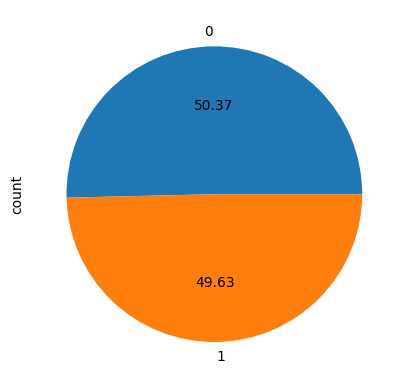

In [ ]:
# Class distribution
# 0 - Fake, 1 - Real
df['label'].value_counts().plot.pie(autopct='%.2f')

**From the graph we understand that we have balanced data.**

### Define X and y variables

In [ ]:
X = df.drop(columns=['label'])
y = df['label']

In [ ]:
messages = X.copy()

# We have to reset index as we have used dropna() earlier, otherwise it will throw an error
messages.reset_index(inplace=True)

### Cleaning text (Tokenization, Stemming, Lemmatization, Remove stopwords)

In [ ]:
import re
from nltk.corpus import stopwords # “the,” “and,” “is,” “in,” “for,” “where,” “when,...
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer


# Initialize the lemmatizer and stemmer
lm = WordNetLemmatizer()
ps = PorterStemmer()

# Initialize an empty list to store the cleaned messages
corpus = []

# Loop through each message in the 'messages' list
for i in range(len(messages)):
    # Remove non-alphanumeric characters from the message title using regex
    review = re.sub('[^a-zA-Z0-9]', ' ', messages['text'][i])

    # Convert the message to lowercase
    review = review.lower()

    # Split the message into individual words
    review = review.split()

    # Lemmatize, stem each word, and remove stopwords
    review = [lm.lemmatize(x) for x in review if x not in stopwords.words('english')]

    # Join the list of words back into a single string
    review = " ".join(review)

    # Append the cleaned message to the corpus list
    corpus.append(review)

In [ ]:
# Need to show corpus after lemma

corpus[0:10]


['pragu reuter czech presid milo zeman plan appoint andrej babi prime minist earli decemb full cabinet around middl month zeman spokesman said thursday babi ano parti came first wide margin parliamentari elect last month fell short major found coalit partner vote support minor cabinet babi tri form czech public televis report thursday zeman want appoint babi dec 6 full cabinet dec 15 presid spokesman said provision date zeman spoke thursday journalist travel state visit russia eight parti parliament far unwil join coalit ano mainli due investig alleg babi hid ownership farm convent center almost decad ago get european union subsidi babi deni wrongdo say case polit motiv new govern take power date appoint lose mandatori confid vote stay offic anoth administr form take month babi appoint possibl current govern prime minist bohuslav sobotka resign expect happen next week earliest far communist said may help ano minor govern confid vote vote alon would enough',
 'hillari clinton plan attac

In [ ]:
# prompt: need to sum of the number of words in the corpus

print(sum(len(sentence.split()) for sentence in corpus))

3132754


In [ ]:
max_length = max(len(sentence.split()) for sentence in corpus)

print("Maximum sentence length:", max_length)

Maximum sentence length: 5205


In [ ]:
len(corpus)

9926

### TF-IDF Vectorization

In [ ]:
tf = TfidfVectorizer(max_features=10000)
x=tf.fit_transform(corpus).toarray()

In [ ]:
# Iterate through the values in x[0] and print the ones that are numbers
for i, val in enumerate(x[1]):
  if val != 0:
    print(f"Index {i}: {val}")


Index 18: 0.039323428892961546
Index 198: 0.06101436094354642
Index 329: 0.027481007744219247
Index 397: 0.040844517223929344
Index 447: 0.04285775922975562
Index 539: 0.033619961686391774
Index 541: 0.020520313772453586
Index 570: 0.09288485633658844
Index 787: 0.039778747738653364
Index 810: 0.06303193036557254
Index 826: 0.050992282192709085
Index 946: 0.08558177865676697
Index 962: 0.03806588575628731
Index 1032: 0.03225297369634667
Index 1101: 0.05024536453156829
Index 1119: 0.09133326237030247
Index 1281: 0.04114489724738957
Index 1469: 0.03378904384536671
Index 1509: 0.13712791881585923
Index 1512: 0.04608396796891047
Index 1530: 0.1365966009547089
Index 1552: 0.05797783693178183
Index 1694: 0.03929864401376271
Index 1771: 0.04403848053936029
Index 1833: 0.03301762074094213
Index 1858: 0.06662242086859584
Index 1879: 0.2424402604137753
Index 2064: 0.04773409720697641
Index 2144: 0.054616916318475074
Index 2224: 0.024843297525466528
Index 2230: 0.0371445508892042
Index 2265: 0.05

In [ ]:
len(x)

9926

In [ ]:
len(x[1]) # size of columns

10000

In [ ]:
y = df["label"]
y.head()

,label
35529,0
29082,0
37123,0
71947,0
15446,0


### Splitting into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True, stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

### Performance Metrics

In [ ]:
y_pred=rf.predict(X_test)

In [ ]:
# Classification report for rf model

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9094    0.8930    0.9011      1000
           1     0.8934    0.9097    0.9015       986

    accuracy                         0.9013      1986
   macro avg     0.9014    0.9014    0.9013      1986
weighted avg     0.9015    0.9013    0.9013      1986



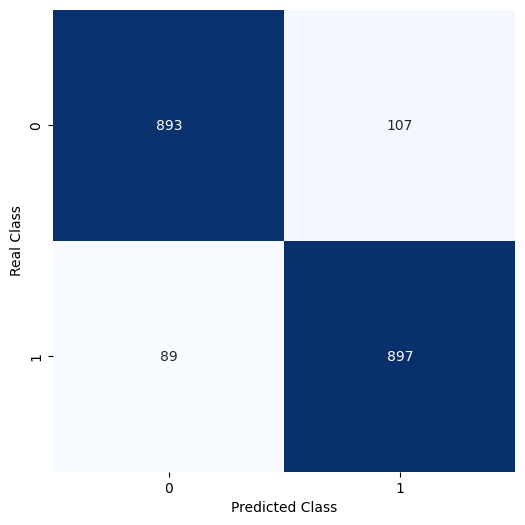

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix oluştur
cm = confusion_matrix(y_test, y_pred)

# Matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.show()

Accuracy: 0.8408862034239678
Precision: 0.8482328482328483
Recall: 0.8275862068965517
F1 Score: 0.837782340862423

Classification Report:
               precision    recall  f1-score   support

           0     0.8340    0.8540    0.8439      1000
           1     0.8482    0.8276    0.8378       986

    accuracy                         0.8409      1986
   macro avg     0.8411    0.8408    0.8408      1986
weighted avg     0.8411    0.8409    0.8408      1986



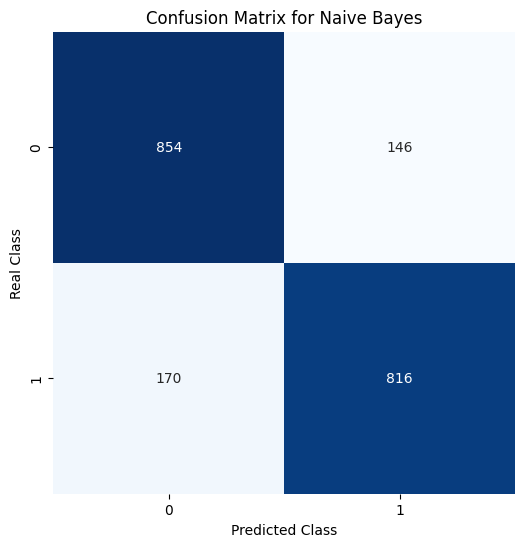

In [ ]:
# Apply Naivebayes with all results

import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Naive Bayes modelini oluştur
nb = MultinomialNB()

# Modeli eğit
nb.fit(X_train, y_train)

# Test verileri üzerinde tahmin yap
y_pred_nb = nb.predict(X_test)

# Performans metriklerini hesapla
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

# Sonuçları yazdır
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Sınıflandırma raporunu yazdır
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, digits=4))

# Confusion matrix oluştur
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


In [ ]:
# Apply all other models in one cell and also ensemble models

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

# Initialize models
logistic_regression = LogisticRegression()
svm = SVC()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
gradient_boosting = GradientBoostingClassifier()
adaboost = AdaBoostClassifier()
xgboost = XGBClassifier()

# Fit models
logistic_regression.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)
adaboost.fit(X_train, y_train)
xgboost.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_regression.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gb = gradient_boosting.predict(X_test)
y_pred_ada = adaboost.predict(X_test)
y_pred_xgb = xgboost.predict(X_test)

# Evaluate individual models
models = [logistic_regression, svm, knn, decision_tree, gradient_boosting, adaboost, xgboost]
model_names = ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Gradient Boosting", "AdaBoost", "XGBoost"]

for model, name in zip(models, model_names):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))
    print("Precision:", precision_score(y_test, model.predict(X_test)))
    print("Recall:", recall_score(y_test, model.predict(X_test)))
    print("F1 Score:", f1_score(y_test, model.predict(X_test)))
    print("\n")

# Ensemble model (Voting Classifier)
ensemble = VotingClassifier(estimators=[
    ('lr', logistic_regression), ('svm', svm), ('knn', knn), ('dt', decision_tree),
    ('gb', gradient_boosting), ('ada', adaboost), ('xgb', xgboost)], voting='hard')
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

print("--- Ensemble (Voting Classifier) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print("Precision:", precision_score(y_test, y_pred_ensemble))
print("Recall:", recall_score(y_test, y_pred_ensemble))
print("F1 Score:", f1_score(y_test, y_pred_ensemble))


--- Logistic Regression ---
Accuracy: 0.9123867069486404
Precision: 0.8988212180746562
Recall: 0.9279918864097363
F1 Score: 0.9131736526946108


--- SVM ---
Accuracy: 0.918429003021148
Precision: 0.9071146245059288
Recall: 0.9310344827586207
F1 Score: 0.9189189189189189


--- KNN ---
Accuracy: 0.5709969788519638
Precision: 0.5369349503858876
Recall: 0.9878296146044625
F1 Score: 0.6957142857142857


--- Decision Tree ---
Accuracy: 0.8655589123867069
Precision: 0.8584247258225324
Recall: 0.8732251521298174
F1 Score: 0.865761689291101


--- Gradient Boosting ---
Accuracy: 0.9098690835850957
Precision: 0.8861244019138756
Recall: 0.9391480730223124
F1 Score: 0.9118660758247169


--- AdaBoost ---
Accuracy: 0.9068479355488419
Precision: 0.9009009009009009
Recall: 0.9127789046653144
F1 Score: 0.906801007556675


--- XGBoost ---
Accuracy: 0.9446122860020141
Precision: 0.932806324110672
Recall: 0.9574036511156186
F1 Score: 0.944944944944945


--- Ensemble (Voting Classifier) ---
Accuracy: 0.9300

In [ ]:
# Apply stacking model

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB

logistic_regression = LogisticRegression()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
logistic_regression = LogisticRegression()
svm = SVC()
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
gradient_boosting = GradientBoostingClassifier()
adaboost = AdaBoostClassifier()
xgboost = XGBClassifier()
nb = MultinomialNB()

# Define base models
base_models = [
    ('lr', logistic_regression),
    ('knn', knn),
    ('dt', decision_tree),
    ('gb', gradient_boosting),
    ('ada', adaboost),
    ('xgb', xgboost),
    ('nb',nb)
]

# Define meta-model
meta_model = LogisticRegression()

# Create stacking classifier
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

# Fit the stacking classifier
stacking_classifier.fit(X_train, y_train)

# Make predictions
y_pred_stacking = stacking_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Evaluate the stacking model
print("--- Stacking Classifier ---")
print("Accuracy:", accuracy_score(y_test, y_pred_stacking))
print("Precision:", precision_score(y_test, y_pred_stacking))
print("Recall:", recall_score(y_test, y_pred_stacking))
print("F1 Score:", f1_score(y_test, y_pred_stacking))

--- Stacking Classifier ---
Accuracy: 0.9420946626384693
Precision: 0.9368104312938816
Recall: 0.947261663286004
F1 Score: 0.9420070600100857
